In [3]:
import librosa
import matplotlib.pyplot as plt
import numpy as np

def process_adc_dac_simulation(
    file_path: str,
    start_sec: float = 1.0,
    duration_ms: float = 10.0,
    num_bits: int = 3,
    downsample_factor: int = 6,
):
    """Mô phỏng quá trình ADC và DAC từ file MP3 và vẽ biểu đồ so sánh.

    Parameters:
    - file_path: Đường dẫn tới file .mp3
    - start_sec: Thời điểm bắt đầu trích xuất âm thanh (giây)
    - duration_ms: Độ dài đoạn âm thanh cần quan sát (mili giây)
    - num_bits: Độ phân giải bit của ADC (VD: 3 bit = 2^3 = 8 mức lượng tử)
    - downsample_factor: Hệ số giảm tần số lấy mẫu cho ADC
    """
    # 1. Giải mã file MP3 thành tín hiệu liên tục (Coi PCM tần số cao là Analog)
    y, sr = librosa.load(file_path, sr=None, mono=True)

    # Trích xuất đoạn ngắn (vài ms) để biểu đồ hiển thị rõ từng bước sóng
    start_sample = int(start_sec * sr)
    num_samples = int((duration_ms / 1000.0) * sr)
    analog_signal = y[start_sample : start_sample + num_samples]
    t_analog = np.linspace(0, duration_ms, len(analog_signal))

    # 2. ADC (Analog-to-Digital Converter)
    # Step A: Lấy mẫu rời rạc theo thời gian (Sampling)
    t_adc = t_analog[::downsample_factor]
    sampled_signal = analog_signal[::downsample_factor]

    # Step B: Lượng tử hóa theo biên độ (Quantization)
    levels = 2**num_bits
    y_min, y_max = np.min(analog_signal), np.max(analog_signal)

    # Chuẩn hóa về khoảng [0, 1] để chia mức
    norm_signal = (sampled_signal - y_min) / (y_max - y_min + 1e-8)
    quantized_norm = (
        np.round(norm_signal * (levels - 1)) / (levels - 1)
    )  # Mã hóa số

    # Biến đổi ngược lại thang biên độ ban đầu (Dữ liệu Digital thu được)
    adc_digital_signal = quantized_norm * (y_max - y_min) + y_min

    # 3. DAC (Digital-to-Analog Converter)
    # Khôi phục tín hiệu liên tục từ các điểm số hóa bằng Zero-Order Hold (ZOH)
    dac_reconstructed = np.repeat(adc_digital_signal, downsample_factor)[
        : len(t_analog)
    ]

    # 4. Trực quan hóa biểu đồ
    plt.figure(figsize=(12, 6))

    # Tín hiệu Analog gốc
    plt.plot(
        t_analog,
        analog_signal,
        label="Analog Gốc (Sóng âm giải mã từ MP3)",
        color="#1f77b4",
        linewidth=2,
        alpha=0.8,
    )

    # Kết quả ADC (Điểm lấy mẫu & Lượng tử hóa)
    plt.stem(
        t_adc,
        adc_digital_signal,
        linefmt="r--",
        markerfmt="ro",
        basefmt=" ",
        label=f"ADC: Lấy mẫu & Lượng tử hóa ({num_bits}-bit, {levels} mức)",
    )

    # Kết quả DAC (Tín hiệu Analog được tái tạo)
    plt.plot(
        t_analog,
        dac_reconstructed,
        label="DAC: Tín hiệu khôi phục (Zero-Order Hold)",
        color="#2ca02c",
        linestyle="-.",
        linewidth=2,
    )

    plt.title(
        f"Mô phỏng Chuyển đổi ADC ({num_bits}-bit) và DAC trên Tín hiệu Âm thanh MP3",
        fontsize=12,
    )
    plt.xlabel("Thời gian (ms)")
    plt.ylabel("Biên độ (Amplitude)")
    plt.legend(loc="upper right")
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.tight_layout()
    plt.show()


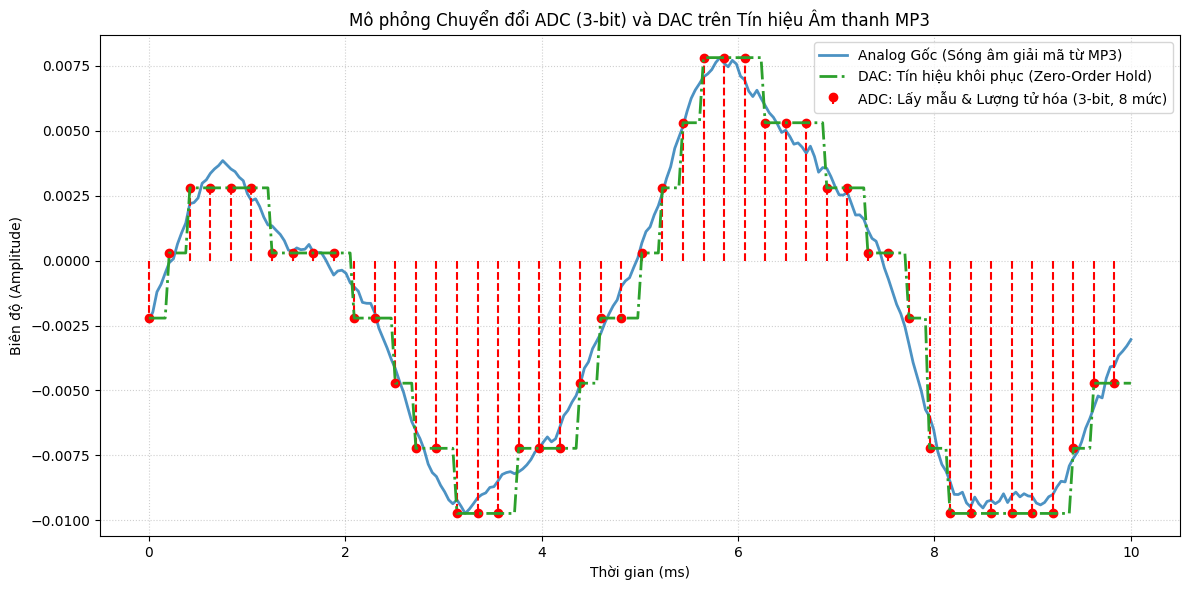

In [4]:
process_adc_dac_simulation(r"E:\s-recognition\data\freesound_community-violin-spiccato-g2-91380.mp3", 
start_sec=2.0, duration_ms=10, num_bits=3, downsample_factor=5)